In [1]:
# imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [2]:
# dataset
df = pd.read_csv("D:\Study\Deep_Learning\Types_of_GD\Social_Network_Ads.csv")

<>:2: SyntaxWarning: invalid escape sequence '\S'
<>:2: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Pradhuman\AppData\Local\Temp\ipykernel_32316\4005418970.py:2: SyntaxWarning: invalid escape sequence '\S'
  df = pd.read_csv("D:\Study\Deep_Learning\Types_of_GD\Social_Network_Ads.csv")


In [3]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
X = df[['Age','EstimatedSalary']]
y = df.iloc[:,-1]

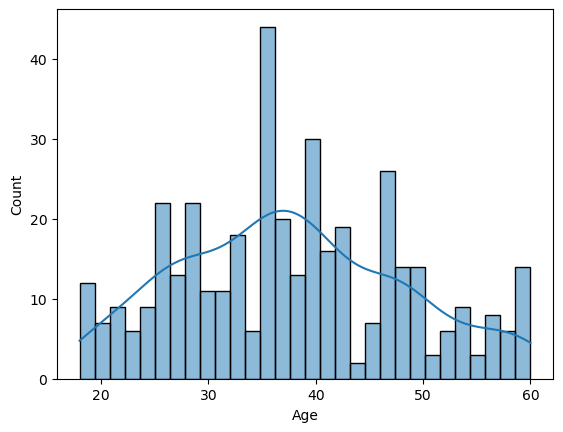

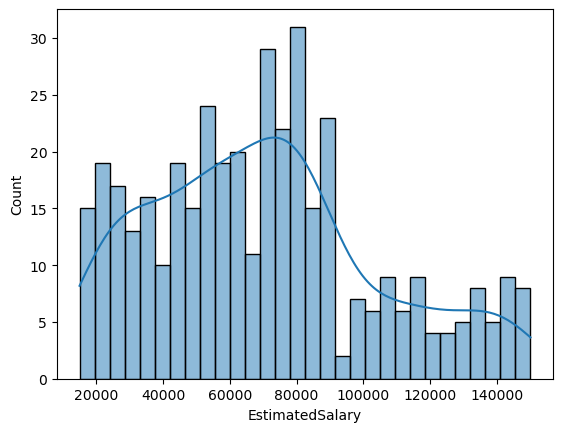

In [9]:
import seaborn as sns

sns.histplot(X['Age'], bins=30, kde=True)
plt.show()
sns.histplot(X['EstimatedSalary'], bins=30, kde=True)
plt.show()

- Check the difference in the scales of the columns

In [5]:
# splitting
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2 , random_state=42)

In [10]:
X_train.shape

(320, 2)

In [11]:
### ANN Model
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(320 , activation='relu', input_dim = 2))
model.add(tf.keras.layers.Dense(1 , activation='sigmoid'))
model.summary()

c:\Users\Pradhuman\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 320)            │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           321 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,281 (5.00 KB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
### Let us check the validation accuracy without Scaling the Input Features
model.compile(loss = "binary_crossentropy" , optimizer="Adam" , metrics=['accuracy'])
history = model.fit(X_train,y_train , validation_data=(X_test,y_test) , epochs=100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5281 - loss: 202.8492 - val_accuracy: 0.3500 - val_loss: 69.4037
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5281 - loss: 135.2665 - val_accuracy: 0.3500 - val_loss: 203.9671
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5219 - loss: 189.9106 - val_accuracy: 0.3500 - val_loss: 222.3876
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4469 - loss: 138.9855 - val_accuracy: 0.6500 - val_loss: 32.5496
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5844 - loss: 75.9612 - val_accuracy: 0.6500 - val_loss: 18.1640
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5281 - loss: 72.7457 - val_accuracy: 0.3500 - val_loss: 88.5645
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5406 - loss: 34.1955 - val_accuracy: 0.6500 - val_loss: 53.6098
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5844 - loss: 79.6565 - va

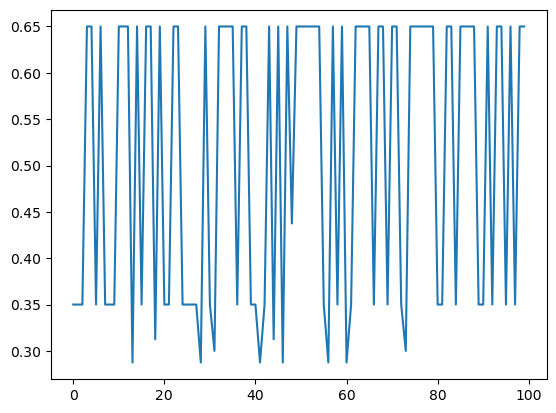

In [14]:
# Plotting the curves
plt.plot(history.history['val_accuracy'])
plt.show()

- See this oscillations of validation accuracy between 0.35 and 0.65, this happens when the Input data is not scaled

### After Scaling

In [19]:
# Let us Scale the data
from sklearn.preprocessing import StandardScaler
scaled = StandardScaler()
X_train_scaled = scaled.fit_transform(X_train)
X_test_scaled = scaled.transform(X_test)

In [20]:
### ANN Model
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(320 , activation='relu', input_dim = 2))
model.add(tf.keras.layers.Dense(1 , activation='sigmoid'))

### Let us check the validation accuracy without Scaling the Input Features
model.compile(loss = "binary_crossentropy" , optimizer="Adam" , metrics=['accuracy'])
history = model.fit(X_train_scaled,y_train , validation_data=(X_test_scaled,y_test) , epochs=100)



Epoch 1/100


c:\Users\Pradhuman\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8094 - loss: 0.6383 - val_accuracy: 0.8750 - val_loss: 0.5694
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8313 - loss: 0.5695 - val_accuracy: 0.8875 - val_loss: 0.4915
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8406 - loss: 0.5131 - val_accuracy: 0.8875 - val_loss: 0.4286
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8313 - loss: 0.4666 - val_accuracy: 0.8875 - val_loss: 0.3799
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8406 - loss: 0.4312 - val_accuracy: 0.9000 - val_loss: 0.3402
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8531 - loss: 0.4003 - val_accuracy: 0.9125 - val_loss: 0.3071
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8687 - loss: 0.3765 - val_accuracy: 0.9125 - val_loss: 0.2804
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8687 - loss: 0.3561 - val_accuracy: 0.9125 - val_loss: 0.

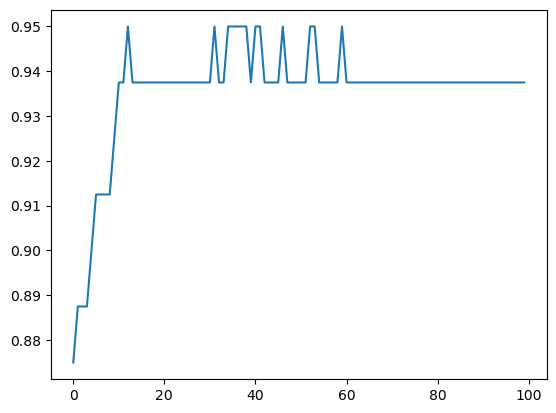

In [21]:
# Plotting the curves
plt.plot(history.history['val_accuracy'])
plt.show()

- See the changes, the validation accuracy increased significantly and did not oscillated.